In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cmocean as cm
import xgcm
import colorcet as ccm

In [2]:
from dask.distributed import Client

In [3]:
c = Client()
c 

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42646 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42646/status,
Dashboard: http://127.0.0.1:42646/status,Workers: 8
Total threads: 48,Total memory: 503.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:32945,Workers: 0
Dashboard: http://127.0.0.1:42646/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41987,Total threads: 6
Dashboard: http://127.0.0.1:42056/status,Memory: 62.90 GiB
Nanny: tcp://127.0.0.1:42082,


In [4]:
from xmitgcm import open_mdsdataset

In [5]:
from utils import *

In [6]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

In [7]:

data = dict(dz8={"PATH":"run_z512_dz8/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz2={"PATH":"run_z512_dz2/", "expt":{}})

ISOBLJ_vels = ISOBLJ_Struct(input_data,data=data)

In [8]:
ISOBLJ_vels.open_datasets(prefix=['vels','state2D'])


ISOBLJ_vels.data['dz8']['expt'].pop("c80m_Td2_vshift8_ryan_dz8");
ISOBLJ_vels.data['dz4']['expt'].pop("c80m_Td2_vshift16_ryan_dz4");

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [9]:
Uvel = ISOBLJ_vels.get_variable("UVEL")
Vvel = ISOBLJ_vels.get_variable("VVEL")
Wvel = ISOBLJ_vels.get_variable("WVEL")

SHIuStar = ISOBLJ_vels.get_variable("SHIuStar")
# ISOBLJ_vels.data

In [10]:
grids = ISOBLJ_vels._get_grid()

In [11]:
def coord_dtype(ds):
    for coord in ds.coords:
        ds[coord]= ds[coord].astype(np.float64)
    return ds

Uvel = coord_dtype(Uvel.astype(float))
Vvel = coord_dtype(Vvel.astype(float))
Wvel = coord_dtype(Wvel.astype(float))

In [12]:
uv_ = []
vv_ = []
wv_ = []

### ADD hFactors


# udvdx vdvdy 

for var in np.sort(Vvel.data_vars):
    print(var)
    grid = grids[var.split("VVEL"+"_")[1]]
    # Uvel_interp = grid.interp(Uvel[var.replace("VVEL","UVEL")],'X',boundary="extend")
    # try:
    dz = int(var.split("dz")[-1])
    if dz==2:
        continue
    zcoord = "Z_dz{0}".format(dz)
    hfacS = Vvel[var.replace("VVEL","hFacS")]
    hfacW = Uvel[var.replace("VVEL","hFacW")]
    
    Vvel_fac = (Vvel[var] * hfacS).rename({zcoord:"Z"})
    Vvel_fac = Vvel_fac.where(Vvel_fac!=0,np.nan)

    Uvel_fac = ( Uvel[var.replace("VVEL","UVEL")] * hfacW ).rename({zcoord:"Z"})
    Uvel_fac = Uvel_fac.where(Uvel_fac!=0,np.nan)

    zcoord_ = "Zl_dz{0}".format(dz)
    Wvel_fac = Wvel[var.replace("VVEL","WVEL")].rename({zcoord_:"Zl"})
    Wvel_fac = Wvel_fac.where(Wvel_fac!=0,np.nan)
    
    Vvel_interp = grid.interp(Vvel_fac,'Y')
    Uvel_interp = grid.interp(Uvel_fac,'X')
    Wvel_interp = grid.interp(Wvel_fac,'Z')
    
    uv_.append((Uvel_interp*(60*4)*Vvel_interp).rename(var.replace("VVEL","udvdx")).rename({"Z":zcoord}))
    vv_.append((Vvel_interp*(60*4)*Vvel_interp).rename(var.replace("VVEL","vdvdy")).rename({"Z":zcoord}))
    wv_.append((Wvel_interp*(60*60)*Vvel_interp).rename(var.replace("VVEL","wdvdz")).rename({"Z":zcoord_}))
    # break
    # except:
        # print(var, " failed")
        # pass`
        
uv = xr.merge(uv_)
vv = xr.merge(vv_)
wv = xr.merge(wv_)



VVEL_c0m_Td01_vshift12_dz8
VVEL_c0m_Td01_vshift24_dz4
VVEL_c0m_Td01_vshift48_dz2
VVEL_c0m_Td05_vshift12_dz8
VVEL_c0m_Td05_vshift24_dz4
VVEL_c0m_Td05_vshift48_dz2
VVEL_c0m_Td1_vshift12_dz8
VVEL_c0m_Td1_vshift24_dz4
VVEL_c0m_Td1_vshift48_dz2
VVEL_c0m_Td2_vshift12_dz8
VVEL_c0m_Td2_vshift24_dz4
VVEL_c0m_Td2_vshift48_dz2
VVEL_c120m_Td01_vshift12_dz8
VVEL_c120m_Td01_vshift24_dz4
VVEL_c120m_Td05_vshift12_dz8
VVEL_c120m_Td05_vshift24_dz4
VVEL_c120m_Td1_vshift12_dz8
VVEL_c120m_Td1_vshift24_dz4
VVEL_c120m_Td2_vshift12_dz8
VVEL_c120m_Td2_vshift24_dz4
VVEL_c160m_Td01_vshift12_dz8
VVEL_c160m_Td01_vshift24_dz4
VVEL_c160m_Td01_vshift48_dz2
VVEL_c160m_Td05_vshift12_dz8
VVEL_c160m_Td05_vshift24_dz4
VVEL_c160m_Td05_vshift48_dz2
VVEL_c160m_Td1_vshift12_dz8
VVEL_c160m_Td1_vshift24_dz4
VVEL_c160m_Td1_vshift48_dz2
VVEL_c160m_Td2_vshift12_dz8
VVEL_c160m_Td2_vshift24_dz4
VVEL_c160m_Td2_vshift48_dz2
VVEL_c20m_Td01_vshift12_dz8
VVEL_c20m_Td01_vshift24_dz4
VVEL_c20m_Td05_vshift12_dz8
VVEL_c20m_Td05_vshift24_dz4


In [13]:
uv_shift = shifted_dataset(uv,method = "du")
vv_shift = shifted_dataset(vv,method = "du")
wv_shift = shifted_dataset(wv,method = "du")

# Output from model

In [14]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

data = dict(dz2={"PATH":"run_z512_dz2/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz8={"PATH":"run_z512_dz8/", "expt":{}})

ISOBLJ_adv = ISOBLJ_Struct(input_data,data=data)

data = dict(dz2={"PATH":"run_z512_dz2/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz8={"PATH":"run_z512_dz8/", "expt":{}})

ISOBLJ_mom = ISOBLJ_Struct(input_data,data=data)

In [15]:
ISOBLJ_adv.open_datasets(prefix=['ADV_terms'])
ISOBLJ_mom.open_datasets(prefix=['MOM_tend'])

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run
expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
exp

In [16]:
ADVx_Um = ISOBLJ_adv.get_variable("ADVx_Um")
ADVy_Um = ISOBLJ_adv.get_variable("ADVy_Um")
ADVrE_Um = ISOBLJ_adv.get_variable("ADVrE_Um")
ADVx_Vm = ISOBLJ_adv.get_variable("ADVx_Vm")
ADVy_Vm = ISOBLJ_adv.get_variable("ADVy_Vm")
ADVrE_Vm = ISOBLJ_adv.get_variable("ADVrE_Vm")

ADVv = ISOBLJ_mom.get_variable("Vm_Advec")

c80m_Td2_vshift16_ryan_dz4 does not have var ADVx_Um
c80m_Td2_vshift16_ryan_dz4 does not have var ADVy_Um
c80m_Td2_vshift16_ryan_dz4 does not have var ADVrE_Um
c80m_Td2_vshift16_ryan_dz4 does not have var ADVx_Vm
c80m_Td2_vshift16_ryan_dz4 does not have var ADVy_Vm
c80m_Td2_vshift16_ryan_dz4 does not have var ADVrE_Vm
c80m_Td2_vshift16_ryan_dz4 does not have var Vm_Advec


In [17]:
ISOBLJ_mom

In [18]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

data = dict(dz2={"PATH":"run_z512_dz2/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz8={"PATH":"run_z512_dz8/", "expt":{}})

ISOBLJ_vel = ISOBLJ_Struct(input_data,data=data)

In [19]:
ISOBLJ_vel.open_datasets(prefix=['vels'])

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [20]:
VVEL = ISOBLJ_vel.get_variable("VVEL")
hfacc_ = shifted_dataset(VVEL.reset_coords(),method = "du")

In [21]:
# hfacc_shifted =  hfacc_.hFacS_c80m_Td1_vshift24_dz4.isel(XC=0).T
# dz=4
# z_shift=-512
# z_ = (abs(((np.sum( 1 - hfacc_shifted ,axis=0))  * dz) + z_shift) + z_shift)
# z_ = np.repeat(z_, 2) 
# # z_£.plot()
# plt.plot(z_)

In [22]:
from matplotlib.collections import PolyCollection
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

def plot_hfacc_surf_shifted(ax,ds,dz,z_shift=512):
    
    x_ = (ds.YC - 60/2000)
    x_ = np.append(np.roll(np.repeat(x_, 2),-1)[:-1], x_[-1]+60/2000)
    Hfacc_shifted = shifted_computations(ds.hFacC,method="du").mean("XC").T

    z_ = (abs(((np.sum( 1 - Hfacc_shifted ,axis=0))  * dz) + z_shift) + z_shift) + dz
    z_ = np.repeat(z_, 2) 

    x = np.append(np.hstack((0 ,x_)),x_[-1]+120/2000)
    if z_shift==-512:
        z = np.append(np.hstack((0 ,z_)),0)
    else:
        z = np.append(np.hstack((z_shift ,z_)),z_shift)

    verts = [np.array(list(zip(x, z)))]
    # print(verts)
    
    poly = PolyCollection(verts, alpha=1, zorder=1,
                          facecolors=[[0.9, 0.9, 0.9]])
    ax.add_collection(poly)

def plot_channel_surface_property(ax,z,ds,dz,freq=1,**kwargs):
    top = ds.dropna("time").isel(time=-1).mean("XC")
    x = ds.YC[::freq] - 60/2000
    cbar = ax.scatter(x, z, c=top,**kwargs)
    return cbar

def extract_channel_coords(ds,dz,shift=0,freq=1):
    z =((np.max(np.cumsum( abs(ds.hFacC.isel(XC=0) -1 ),axis=0),axis=0) * -dz) + 512 + shift )[::freq]
    return z

z = extract_channel_coords(VVEL["hFacS_c80m_Td2_vshift48_dz2"].rename({"hFacS_c80m_Td2_vshift48_dz2":"hFacC"}),dz=2)

In [23]:
def VAR_withBL_TopZ(ds_vel,adv,grids,var='VVEL',dims="X"):
    ds_return=[]
    for dvar in adv.data_vars:
        print(dvar)
        dz = int(dvar.split("dz")[-1])
        z_coord = "Z_dz{0}".format(dz)
        grid_name = "_".join(dvar.split("_")[2:])
        hfacc_var = ds_vel["hFacS_"+grid_name].rename({z_coord:"Z"})
        grid = grids[grid_name]
        # hfacc_var = grid.interp(grid.interp(hfacc_var,'Y'),'X')
        if dims=="Z":
            data = adv.reset_coords(drop=True)[dvar].rename({z_coord.replace("Z","Zl"):"Zl"})
        else:
            data = adv.reset_coords(drop=True)[dvar].rename({z_coord:"Z"})

        volx = (60*60*hfacc_var*dz)
        
        adv_ = grid.diff(data.mean("time"),dims).where(hfacc_var!=0,0)/volx
        
        adv_shift = shifted_computations(adv_,method = "ud")

        # break
    # return adv_shift
    #     # shifted_computations(adv_,method = "ud")
    #     # print(adv_)
    #     #This only works for a constant dz
        hfacc_shifted = shifted_computations(hfacc_var, method="ud",dims=["Z"] )
        
        drK0 = hfacc_shifted.isel({"Z":0}) * dz
        drK1 = (1 - hfacc_shifted.isel({"Z":0})) * dz
        
        recip_drLoc = 1/ ( drK0 + drK1 )
        advvar = (adv_shift.isel({"Z":0}) * drK0 + adv_shift.isel({"Z":1}) * drK1)

        weighted_var = adv_shift.isel({"Z":0}) #
        weighted_var = advvar*recip_drLoc
        # break
    # return weighted_var
        ds_return.append(weighted_var.rename(dvar).rename({"Z":z_coord}))
        # break
        
    return xr.merge(ds_return)


In [24]:
Vvel = ISOBLJ_vel.get_variable("VVEL")

In [25]:
ADVx_Vm_vars = ADVx_Vm[[ "ADVx_Vm_c80m_Td2_vshift48_dz2","ADVx_Vm_c80m_Td2_vshift24_dz4","ADVx_Vm_c80m_Td2_vshift12_dz8",
                        "ADVx_Vm_c160m_Td2_vshift48_dz2","ADVx_Vm_c160m_Td2_vshift24_dz4","ADVx_Vm_c160m_Td2_vshift12_dz8" ]]

ADVx_Vm_surf = VAR_withBL_TopZ(Vvel,ADVx_Vm_vars,grids,dims="X")

ADVx_Vm_c80m_Td2_vshift48_dz2
ADVx_Vm_c80m_Td2_vshift24_dz4
ADVx_Vm_c80m_Td2_vshift12_dz8
ADVx_Vm_c160m_Td2_vshift48_dz2
ADVx_Vm_c160m_Td2_vshift24_dz4
ADVx_Vm_c160m_Td2_vshift12_dz8


In [26]:
ADVy_Vm_vars = ADVy_Vm[[ "ADVy_Vm_c80m_Td2_vshift48_dz2","ADVy_Vm_c80m_Td2_vshift24_dz4","ADVy_Vm_c80m_Td2_vshift12_dz8",
                       "ADVy_Vm_c160m_Td2_vshift48_dz2","ADVy_Vm_c160m_Td2_vshift24_dz4","ADVy_Vm_c160m_Td2_vshift12_dz8" ]]

ADVy_Vm_surf = VAR_withBL_TopZ(Vvel,ADVy_Vm_vars,grids,dims="Y")

ADVy_Vm_c80m_Td2_vshift48_dz2
ADVy_Vm_c80m_Td2_vshift24_dz4
ADVy_Vm_c80m_Td2_vshift12_dz8
ADVy_Vm_c160m_Td2_vshift48_dz2
ADVy_Vm_c160m_Td2_vshift24_dz4
ADVy_Vm_c160m_Td2_vshift12_dz8


In [27]:
ADVrE_Vm_vars = ADVrE_Vm[[ "ADVrE_Vm_c80m_Td2_vshift48_dz2","ADVrE_Vm_c80m_Td2_vshift24_dz4","ADVrE_Vm_c80m_Td2_vshift12_dz8",
                         "ADVrE_Vm_c160m_Td2_vshift48_dz2","ADVrE_Vm_c160m_Td2_vshift24_dz4","ADVrE_Vm_c160m_Td2_vshift12_dz8"]]

ADVrE_Vm_surf = VAR_withBL_TopZ(Vvel,ADVrE_Vm_vars,grids,dims="Z")

ADVrE_Vm_c80m_Td2_vshift48_dz2
ADVrE_Vm_c80m_Td2_vshift24_dz4
ADVrE_Vm_c80m_Td2_vshift12_dz8
ADVrE_Vm_c160m_Td2_vshift48_dz2
ADVrE_Vm_c160m_Td2_vshift24_dz4
ADVrE_Vm_c160m_Td2_vshift12_dz8


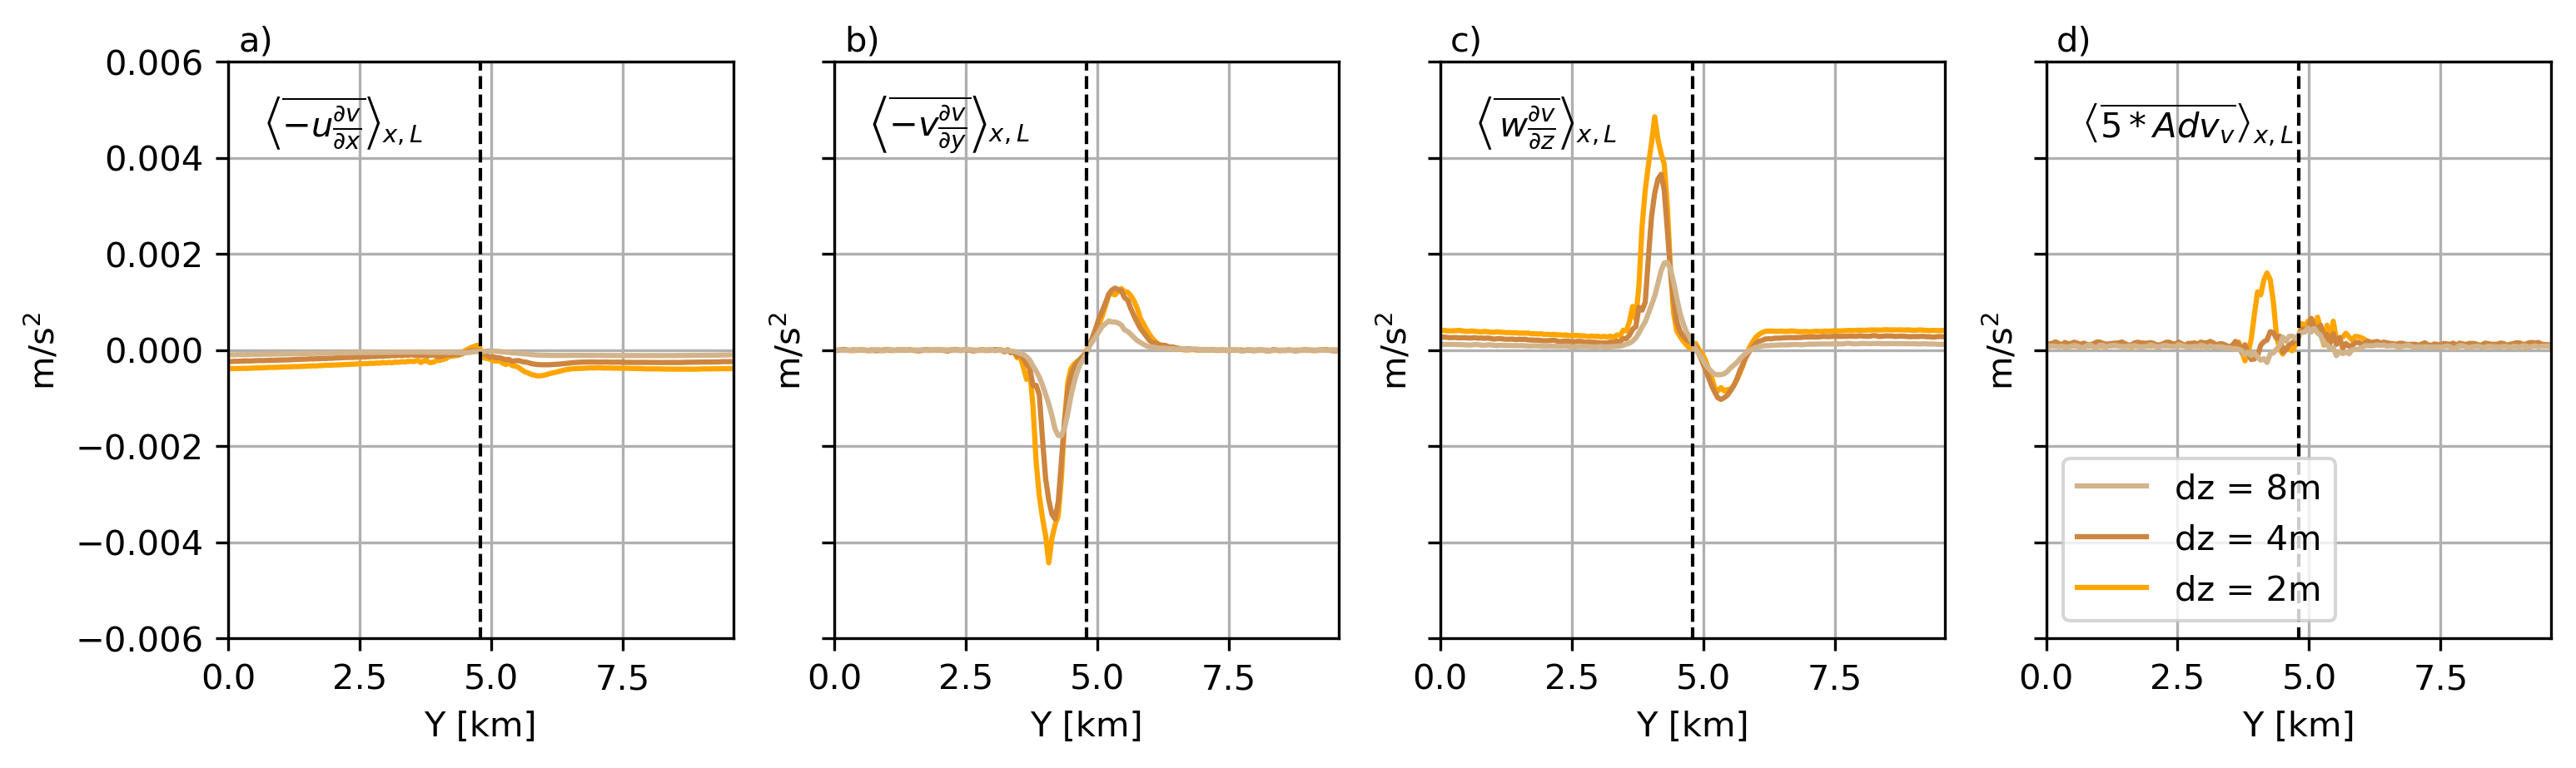

In [30]:
# ADVx_Vm_shift.ADVx_Vm_c120m_Td2_vshift24_dz4
# ADVy_Vm_shift.ADVy_Vm_c120m_Td2_vshift24_dz4
# ADVrE_Vm_shift.ADVrE_Vm_c120m_Td2_vshift24_dz4

fig,ax = plt.subplots(1,4,figsize=(12,3),dpi=300,sharey=True, sharex=True)


grids = ISOBLJ_vel._get_grid()


grid = grids["c80m_Td2_vshift48_dz2"]

udvdx = -ADVx_Vm_surf.ADVx_Vm_c80m_Td2_vshift48_dz2
vdvdy = -ADVy_Vm_surf.ADVy_Vm_c80m_Td2_vshift48_dz2
wdvdz = ADVrE_Vm_surf.ADVrE_Vm_c80m_Td2_vshift48_dz2

cbar1 = (udvdx).mean("XC").plot(x="YG",ax=ax[0],color="orange")

(vdvdy).mean("XC").plot(x="YG",ax=ax[1],color="orange")

(wdvdz).mean("XC").plot(x="YG",ax=ax[2],color="orange")

adv1 = 5*(udvdx + vdvdy + wdvdz).mean("XC")

adv1.plot(x="YG",ax=ax[3],color="orange")

grid = grids["c80m_Td2_vshift48_dz2"]

########################################################################
########################################################################
########################################################################

grid = grids["c80m_Td2_vshift24_dz4"]

udvdx = -ADVx_Vm_surf.ADVx_Vm_c80m_Td2_vshift24_dz4
vdvdy = -ADVy_Vm_surf.ADVy_Vm_c80m_Td2_vshift24_dz4
wdvdz = ADVrE_Vm_surf.ADVrE_Vm_c80m_Td2_vshift24_dz4

cbar1 = (udvdx).mean("XC").plot(x="YG",ax=ax[0],color="peru")

(vdvdy).mean("XC").plot(x="YG",ax=ax[1],color="peru")

(wdvdz).mean("XC").plot(x="YG",ax=ax[2],color="peru")

adv2 = 5*(udvdx + vdvdy + wdvdz).mean("XC")

adv2.plot(x="YG",ax=ax[3],color="peru")

grid = grids["c80m_Td2_vshift24_dz4"]


########################################################################
########################################################################
########################################################################

grid = grids["c80m_Td2_vshift12_dz8"]

udvdx = -ADVx_Vm_surf.ADVx_Vm_c80m_Td2_vshift12_dz8
vdvdy = -ADVy_Vm_surf.ADVy_Vm_c80m_Td2_vshift12_dz8
wdvdz = ADVrE_Vm_surf.ADVrE_Vm_c80m_Td2_vshift12_dz8

cbar2 = (udvdx).mean("XC").plot(x="YG",ax=ax[0],color="tan")

(vdvdy).mean("XC").plot(x="YG",ax=ax[1],color="tan")

(wdvdz).mean("XC").plot(x="YG",ax=ax[2],color="tan")

adv3 = 5*(udvdx + vdvdy + wdvdz).mean("XC")

adv3.plot(x="YG",ax=ax[3],color="tan")

grid = grids["c80m_Td2_vshift12_dz8"]

# ########################################################################
# ########################################################################
# ########################################################################


for a in ax.ravel():
    a.plot(np.ones(2)*ADVx_Vm_surf.YG[80].values,[-0.012,0.012],linestyle='--',color='k',linewidth=1)

[a.set_ylabel("") for a in ax.ravel()]
[a.set_xlabel("") for a in ax.ravel()]
[a.set_ylim(-0.006,0.006) for a in ax.ravel()]
[a.set_xlim(0,9.6) for a in ax.ravel()]
[a.grid() for a in ax.ravel()]


[a.set_title("") for a in ax.ravel()]

[a.set_ylabel(r"$\mathrm{m/s}^2$") for a in ax[:]]
[a.set_xlabel("Y [km]") for a in ax[:]]

ax[0].text(0.02, 1.02, "a)", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.02, 1.02, "b)", fontsize=10, transform=ax[1].transAxes)
ax[2].text(0.02, 1.02, "c)", fontsize=10, transform=ax[2].transAxes)
ax[3].text(0.02, 1.02, "d)", fontsize=10, transform=ax[3].transAxes)

ax[0].text(0.07, 0.87, r"$\left<\overline{-u\frac{\partial v}{\partial x}}\right>_{x,L}$", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.07, 0.87, r"$\left<\overline{-v\frac{\partial v}{\partial y}}\right>_{x,L}$", fontsize=10, transform=ax[1].transAxes)
ax[2].text(0.07, 0.87, r"$\left<\overline{\,w\frac{\partial v}{\partial z}}\right>_{x,L}$", fontsize=10, transform=ax[2].transAxes)
ax[3].text(0.07, 0.87, r"$\left<\overline{5*Adv_v}\right>_{x,L}$", fontsize=10, transform=ax[3].transAxes)

ax[3].plot(0,0,color='tan',label="dz = 8m",linestyle='-')
ax[3].plot(0,0,color='peru',label="dz = 4m",linestyle='-')
ax[3].plot(0,0,color='orange',label="dz = 2m",linestyle='-')
ax[3].legend()

plt.savefig('./figures/Fig_10_advection_boundary.pdf', dpi=300, bbox_inches='tight')

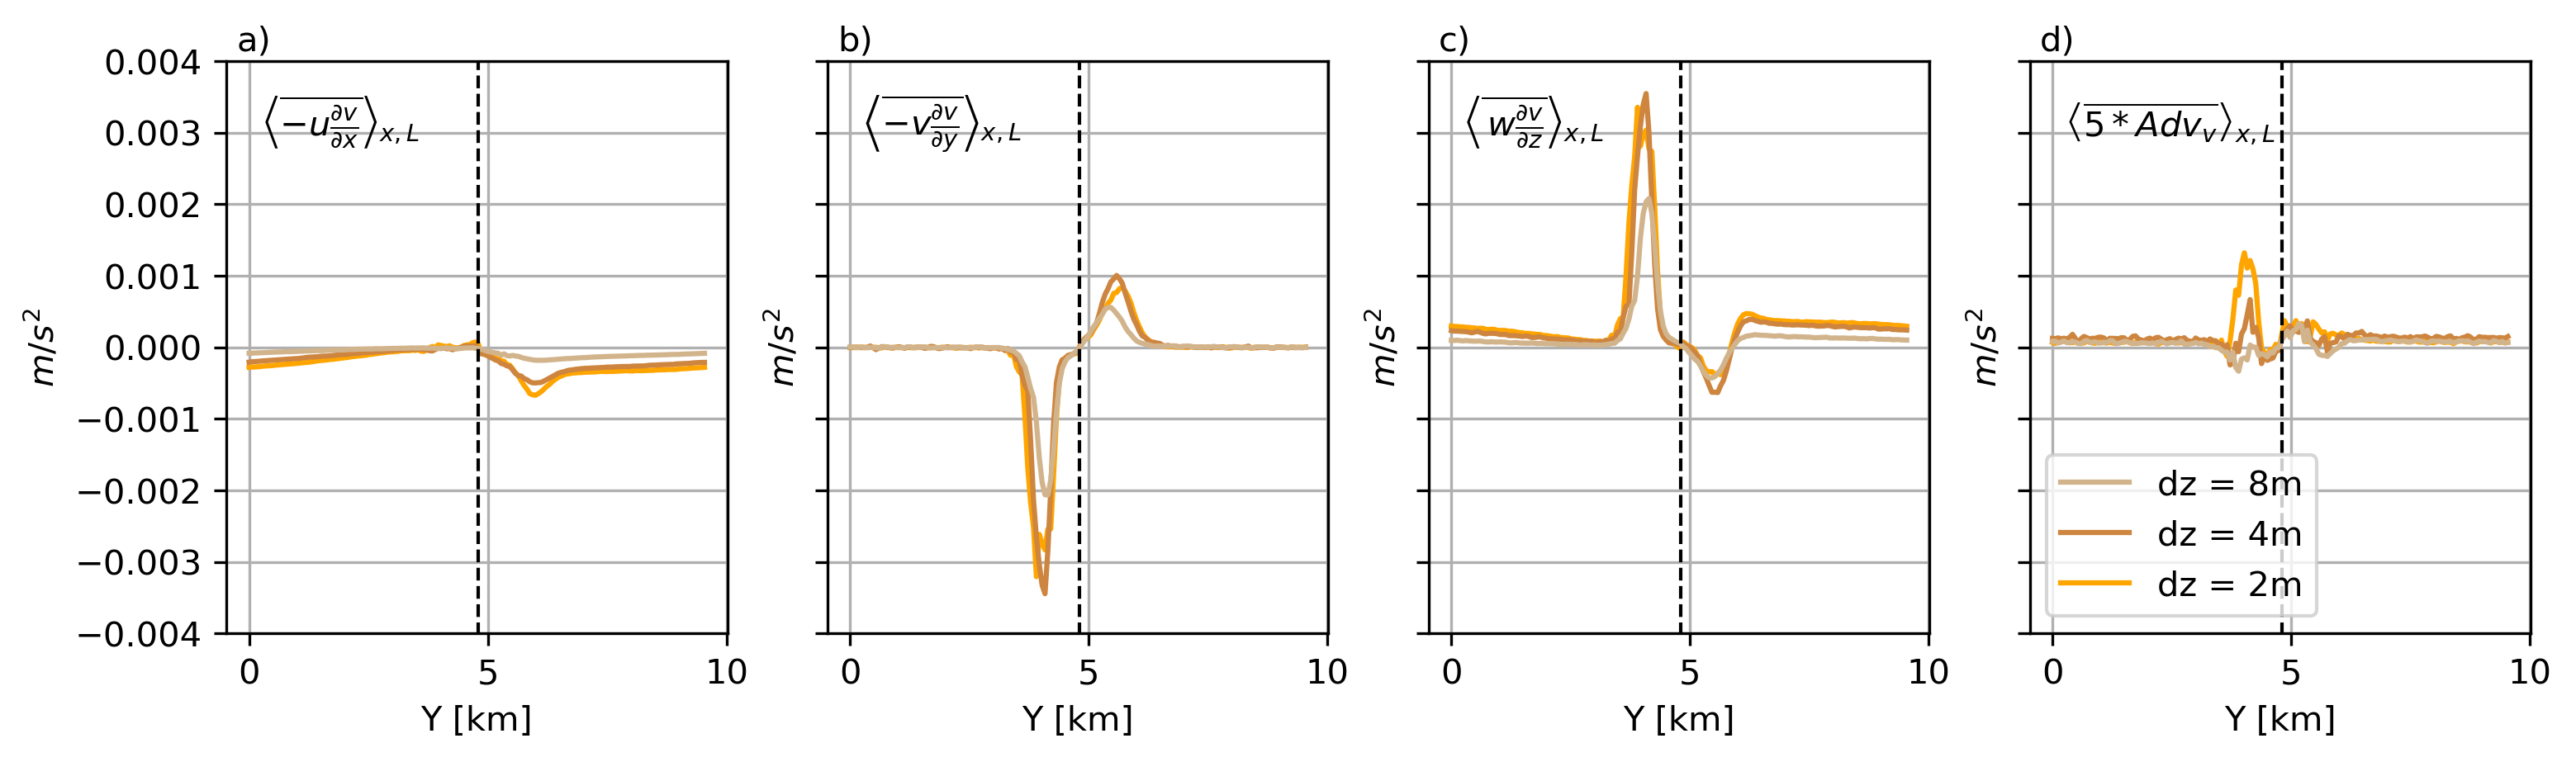

In [33]:
# ADVx_Vm_shift.ADVx_Vm_c120m_Td2_vshift24_dz4
# ADVy_Vm_shift.ADVy_Vm_c120m_Td2_vshift24_dz4
# ADVrE_Vm_shift.ADVrE_Vm_c120m_Td2_vshift24_dz4

fig,ax = plt.subplots(1,4,figsize=(12,3),dpi=300,sharey=True, sharex=True)


grids = ISOBLJ_vel._get_grid()


grid = grids["c160m_Td2_vshift48_dz2"]

udvdx = -ADVx_Vm_surf.ADVx_Vm_c160m_Td2_vshift48_dz2
vdvdy = -ADVy_Vm_surf.ADVy_Vm_c160m_Td2_vshift48_dz2
wdvdz = ADVrE_Vm_surf.ADVrE_Vm_c160m_Td2_vshift48_dz2

cbar1 = (udvdx).mean("XC").plot(x="YG",ax=ax[0],color="orange")

(vdvdy).mean("XC").plot(x="YG",ax=ax[1],color="orange")

(wdvdz).mean("XC").plot(x="YG",ax=ax[2],color="orange")

adv1 = 5*(udvdx + vdvdy + wdvdz).mean("XC")

adv1.plot(x="YG",ax=ax[3],color="orange")

grid = grids["c160m_Td2_vshift48_dz2"]

########################################################################
########################################################################
########################################################################

grid = grids["c160m_Td2_vshift24_dz4"]

udvdx = -ADVx_Vm_surf.ADVx_Vm_c160m_Td2_vshift24_dz4
vdvdy = -ADVy_Vm_surf.ADVy_Vm_c160m_Td2_vshift24_dz4
wdvdz = ADVrE_Vm_surf.ADVrE_Vm_c160m_Td2_vshift24_dz4

cbar1 = (udvdx).mean("XC").plot(x="YG",ax=ax[0],color="peru")

(vdvdy).mean("XC").plot(x="YG",ax=ax[1],color="peru")

(wdvdz).mean("XC").plot(x="YG",ax=ax[2],color="peru")

adv2 = 5*(udvdx + vdvdy + wdvdz).mean("XC")

adv2.plot(x="YG",ax=ax[3],color="peru")

grid = grids["c160m_Td2_vshift24_dz4"]


########################################################################
########################################################################
########################################################################

grid = grids["c160m_Td2_vshift12_dz8"]

udvdx = -ADVx_Vm_surf.ADVx_Vm_c160m_Td2_vshift12_dz8
vdvdy = -ADVy_Vm_surf.ADVy_Vm_c160m_Td2_vshift12_dz8
wdvdz = ADVrE_Vm_surf.ADVrE_Vm_c160m_Td2_vshift12_dz8

cbar2 = (udvdx).mean("XC").plot(x="YG",ax=ax[0],color="tan")

(vdvdy).mean("XC").plot(x="YG",ax=ax[1],color="tan")

(wdvdz).mean("XC").plot(x="YG",ax=ax[2],color="tan")

adv3 = 5*(udvdx + vdvdy + wdvdz).mean("XC")

adv3.plot(x="YG",ax=ax[3],color="tan")

grid = grids["c160m_Td2_vshift12_dz8"]

# ########################################################################
# ########################################################################
# ########################################################################


for a in ax.ravel():
    a.plot(np.ones(2)*ADVx_Vm_surf.YG[80].values,[-0.01,0.01],linestyle='--',color='k',linewidth=1)

[a.set_ylabel("") for a in ax.ravel()]
[a.set_xlabel("") for a in ax.ravel()]
[a.set_ylim(-0.004,0.004) for a in ax.ravel()]
[a.grid() for a in ax.ravel()]

[a.set_title("") for a in ax.ravel()]

[a.set_ylabel("$m/s^2$") for a in ax[:]]
[a.set_xlabel("Y [km]") for a in ax[:]]

ax[0].text(0.02, 1.02, "a)", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.02, 1.02, "b)", fontsize=10, transform=ax[1].transAxes)
ax[2].text(0.02, 1.02, "c)", fontsize=10, transform=ax[2].transAxes)
ax[3].text(0.02, 1.02, "d)", fontsize=10, transform=ax[3].transAxes)

ax[0].text(0.07, 0.87, r"$\left<\overline{-u\frac{\partial v}{\partial x}}\right>_{x,L}$", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.07, 0.87, r"$\left<\overline{-v\frac{\partial v}{\partial y}}\right>_{x,L}$", fontsize=10, transform=ax[1].transAxes)
ax[2].text(0.07, 0.87, r"$\left<\overline{\,w\frac{\partial v}{\partial z}}\right>_{x,L}$", fontsize=10, transform=ax[2].transAxes)
ax[3].text(0.07, 0.87, r"$\left<\overline{5*Adv_v}\right>_{x,L}$", fontsize=10, transform=ax[3].transAxes)

ax[3].plot(0,0,color='tan',label="dz = 8m",linestyle='-')
ax[3].plot(0,0,color='peru',label="dz = 4m",linestyle='-')
ax[3].plot(0,0,color='orange',label="dz = 2m",linestyle='-')
ax[3].legend()

plt.savefig('./figures/SFig_4_advection_c160m.pdf', dpi=300, bbox_inches='tight')